# Naïve Bayes — Gaussian NB and Multinomial NB

This notebook implements two Naive Bayes variants described in `notes.md`:

1. **Gaussian Naive Bayes** on `load_iris` (continuous features).
2. **Multinomial Naive Bayes** on text data from `fetch_20newsgroups` (word-count features), for the two categories `sci.space` and `rec.sport.hockey`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline


## 1) Gaussian Naive Bayes on Iris

`GaussianNB` assumes each feature is normally distributed within each class — a good fit for the continuous, roughly bell-shaped measurements in the Iris dataset.

In [2]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_iris = gnb.predict(X_test)

acc_iris = accuracy_score(y_test, y_pred_iris)
print(f"GaussianNB accuracy on Iris test set: {acc_iris:.4f}")


GaussianNB accuracy on Iris test set: 0.9111


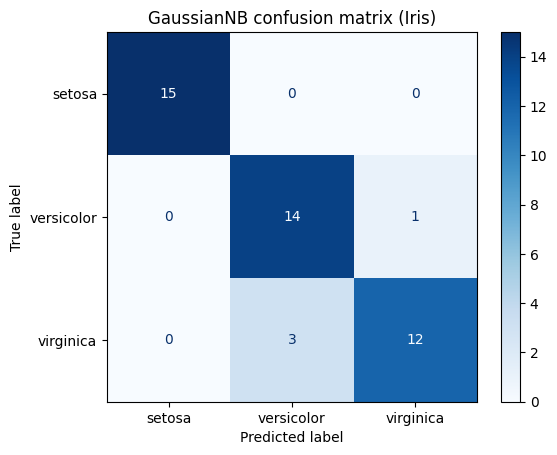

In [3]:
cm_iris = confusion_matrix(y_test, y_pred_iris)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_iris, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title("GaussianNB confusion matrix (Iris)")
plt.show()


## 2) Multinomial Naive Bayes on Text (20 Newsgroups)

`MultinomialNB` is built for discrete counts — the classic use case is word-frequency features from text. We restrict to two clearly separable categories: `sci.space` and `rec.sport.hockey`, vectorize the raw text with `CountVectorizer` (bag-of-words), and classify.

In [4]:
categories = ["sci.space", "rec.sport.hockey"]

news_train = fetch_20newsgroups(
    subset="train", categories=categories, remove=("headers", "footers", "quotes"),
    random_state=42,
)
news_test = fetch_20newsgroups(
    subset="test", categories=categories, remove=("headers", "footers", "quotes"),
    random_state=42,
)

print(f"Train documents: {len(news_train.data)}, Test documents: {len(news_test.data)}")
print("Categories:", news_train.target_names)


Train documents: 1193, Test documents: 793
Categories: ['rec.sport.hockey', 'sci.space']


In [5]:
vectorizer = CountVectorizer(stop_words="english", max_features=5000)
X_train_counts = vectorizer.fit_transform(news_train.data)
X_test_counts = vectorizer.transform(news_test.data)

print(f"Vocabulary size (capped): {len(vectorizer.vocabulary_)}")
print(f"Train matrix shape: {X_train_counts.shape}")


Vocabulary size (capped): 5000
Train matrix shape: (1193, 5000)


In [6]:
mnb = MultinomialNB()
mnb.fit(X_train_counts, news_train.target)
y_pred_news = mnb.predict(X_test_counts)

acc_news = accuracy_score(news_test.target, y_pred_news)
print(f"MultinomialNB accuracy on 20 Newsgroups test set: {acc_news:.4f}")


MultinomialNB accuracy on 20 Newsgroups test set: 0.9357


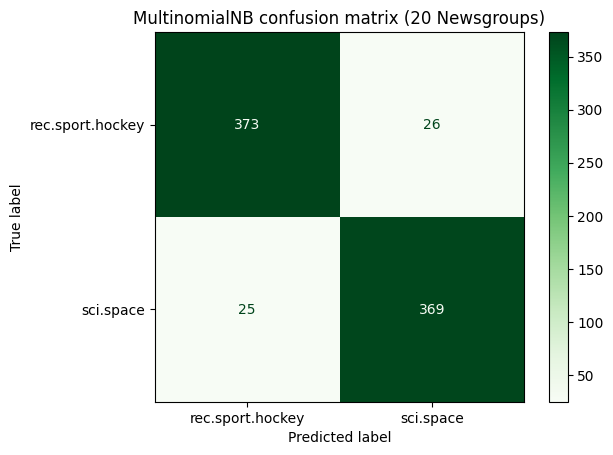

In [7]:
cm_news = confusion_matrix(news_test.target, y_pred_news)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_news, display_labels=news_train.target_names)
disp.plot(cmap="Greens")
plt.title("MultinomialNB confusion matrix (20 Newsgroups)")
plt.show()


## Takeaway

- `GaussianNB` works well on Iris because its four continuous measurements are approximately normally distributed within each species class.
- `MultinomialNB` works well on bag-of-words text counts because the "naive" independence assumption over word occurrences, while technically wrong (words are correlated), still yields a strong and very fast baseline classifier — here achieving high accuracy separating hockey articles from space articles based purely on vocabulary.